# RL2 - Notebook 2 - Monte-Carlo control

In this notebook, you will explore how to estimate state value function ($v^{\pi}$), and state-action value functions ($q^{\pi}$) with monte-carlo methods and to use the latter (Q-values) to optimise control.


In [1]:
import numpy as np
import matplotlib.pyplot as plt

from inst0075.rl.environment.simulation import Trace
from inst0075.rl.environment.simulation import Simulation
from inst0075.rl.environment.simulation import MDPSimulation

from inst0075.rl.algorithms.dynamic_programming import policy_evaluation
from inst0075.rl.algorithms.monte_carlo import monte_carlo_evaluation
from inst0075.rl.algorithms.monte_carlo import monte_carlo_q_evaluation
from inst0075.rl.algorithms.monte_carlo import monte_carlo_batch_optimisation
from inst0075.rl.algorithms.monte_carlo import monte_carlo_iterative_optimisation

from inst0075.rl.environment.states_and_actions import dominant_actions
from inst0075.rl.environment.states_and_actions import indices_to_names

from inst0075.rl.environment.states_and_actions import get_unbiased_policy
from inst0075.rl.environment.states_and_actions import get_greedy_policy
from inst0075.rl.environment.states_and_actions import get_epsilon_greedy_policy

import inst0075.rl.environment.model.example_mdps as example_mdps
import inst0075.rl.environment.model.example_grid_worlds as example_grid_worlds 

from inst0075.rl.visualisation import (
    plot_mdp_matrices,
    plot_policy_matrix,
    report_mdp_summary,
    line_plot_value_convergence,
    plot_value_function,
    plot_q_function
)


## Monte-carlo evaluation

Here we create a simulation object from a grid-world MDP and use **monte-carlo evaluation** to estimate the value function for the unbiased policy. We compare this with the trusted estimates for the value function which we get from Policy evaluation- the dynamic programming method we saw in the previous unit.

V = array([ 0.        , -6.79667969, -2.54678769,  0.10782447,  2.89673083,
        7.15029892,  0.        ])


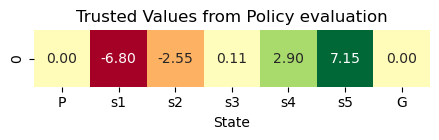

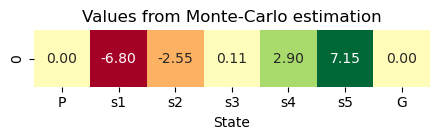

In [2]:
# create mdp and simulation objects
stair_mdp = example_mdps.stair_climbing_mdp()
stair_sim = MDPSimulation(stair_mdp)
unbiased_policy = get_unbiased_policy(
    stair_mdp.num_states, stair_mdp.num_actions)

# explore monte carlo evaluation
gamma = 0.9
num_episodes = 100
V_trusted = policy_evaluation(
    stair_sim, gamma, unbiased_policy)
V = monte_carlo_evaluation(
    stair_sim, gamma, unbiased_policy, num_episodes=num_episodes)
print("V = %r" % (V,))
plot_value_function(V, stair_mdp, title="Trusted Values from Policy evaluation")
plot_value_function(V, stair_mdp, title="Values from Monte-Carlo estimation")

## Monte-carlo estimation convergence

To see how efficiently Monte-carlo estimation learns, we compare the value estimates from Monte-carlo with estimates from Dynamic programming, which is more efficient but requires access to the MDP model. The plot shows that, as we would expect from estimates based on random samples, Monte-carlo estimation (MC) gives noisy approximations of the dynamic programming result (DP).

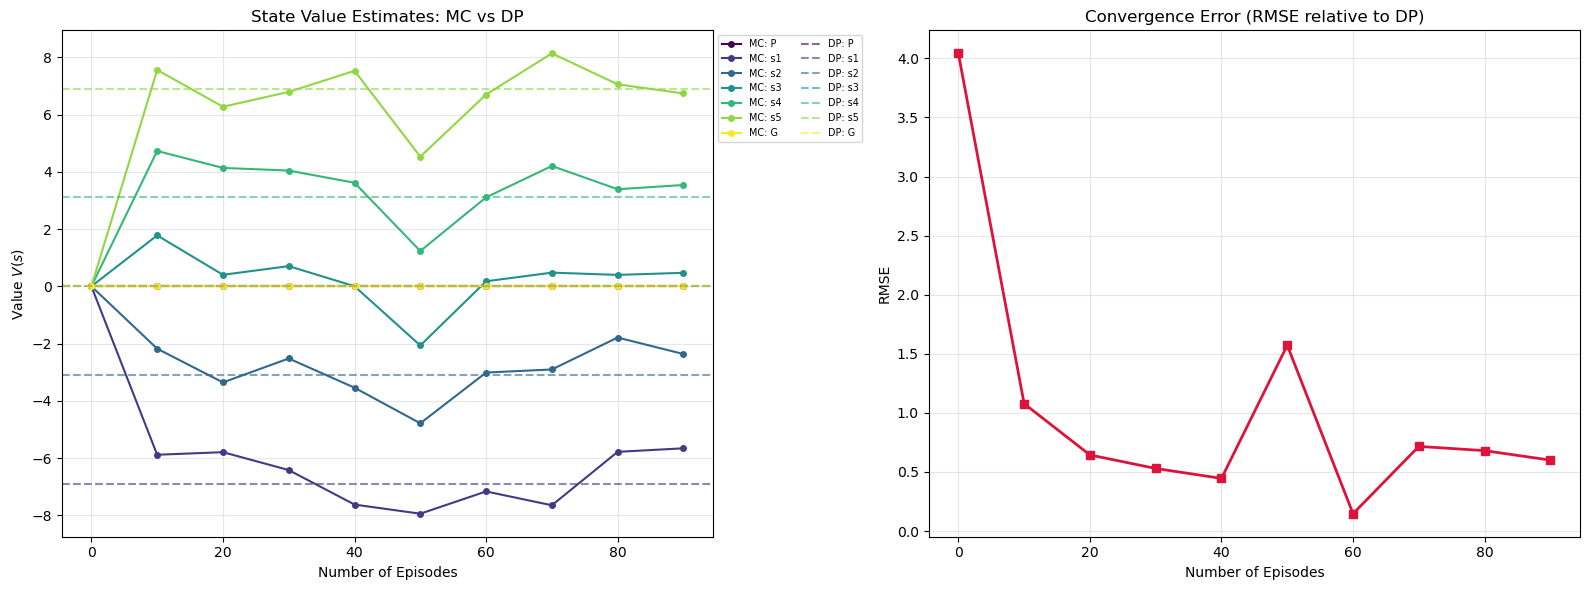

In [3]:
# explore monte carlo evaluation convergence
gamma = 0.9
V_trusted = policy_evaluation(
    stair_sim, gamma, unbiased_policy)

num_episodes_seq = np.arange(0,100,10)
all_v_estimates = np.zeros((num_episodes_seq.size, stair_sim.num_states))
for e, num_episodes in enumerate(num_episodes_seq):
    all_v_estimates[e,:] = monte_carlo_evaluation(
        stair_sim, gamma, unbiased_policy, num_episodes=num_episodes)

line_plot_value_convergence(num_episodes_seq, all_v_estimates, V_trusted, stair_mdp.state_names)

## Monte-carlo q-estimation

As discussed in the lectures, we can use monte-carlo to estimate state-action value functions, $q^{\pi}$, in much the same way that we estimate state value functions $v^{\pi}$. We call these estimates $\hat{q}$. There is one such estimate for each state, s, and action, a, i.e. $\hat{q}(s,a)$.

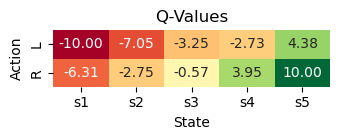

In [4]:
Q = monte_carlo_q_evaluation(stair_sim, gamma, unbiased_policy, 10)
plot_q_function(Q, stair_sim, states_as_rows=False)

## Greedy policy from q-function estimates

Given Q function estiamtes, we now have a guess/estimate of which action leads to the best result in each state. We can derive a policy from these estimates directly. One way to do this is just choosing the greedy policy, $\pi_{\text{greedy}}$ where for all states, s, and actions, a:
$$
\pi_{\text{greedy}}(s,a) = 
\begin{cases}
1 & \text{if } a = \arg\max_{b}  \hat{q}(s, b) \\
0 & \text{otherwise}
\end{cases}
$$

It should be straight-forward to see the parallels between this and the greedy policy selection used in Dynamic programming. The cell below derives a policy from our estimates above in just this way.

 

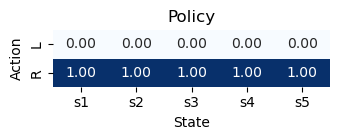

In [5]:
greedy_policy = get_greedy_policy(Q, absorbing=stair_mdp.absorbing)
plot_policy_matrix(greedy_policy, stair_sim, states_as_rows=False)

## $\varepsilon$-greedy policies

Note that this is sufficiently powerful to converge on the optimal policy for this simple MDP in just one step. More complex MDPs may require multiple rounds of estimation and policy adaptation. However, as discussed in the lectures, deterministic policies are not good at exploring all state-action pairs sufficiently and moving to these too early can interfere with learning a fully optimal policy. Instead, we need to encode a degree of exploration into the control policy during learning.

One such way to ensure continued exploration is with an $\varepsilon$-greedy (epsilon-greedy) policy. Put simply, this chooses the greedy action most of the time (with probability $1- \varepsilon$) and acts randomly for the rest of the time. Given some set of estimates $\hat{q}$ the associated $\varepsilon$-greedy policy, $\pi = \varepsilon\textit{-greedy}(\hat{q})$ is given by:
$$
  \pi(s,a) =
  \begin{cases}
  1-\varepsilon + \frac{\varepsilon}{\lvert \mathcal{A}\rvert} & \text{for} \; a = \arg\max_{a'}\hat{q}(s,a') \\
  \frac{\varepsilon}{\lvert\mathcal{A}\rvert} & \text{otherwise}
  \end{cases}
$$

The cell below calculates and visualises the $\varepsilon$-greedy policy for our state-action value estimate $\hat{q}$ with $\varepsilon = 0.1$


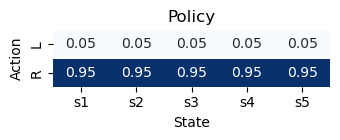

In [6]:
epsilon = 0.1
greedy_policy = get_epsilon_greedy_policy(epsilon, Q, absorbing=stair_mdp.absorbing)
plot_policy_matrix(greedy_policy, stair_sim, states_as_rows=False)

## Monte-carlo batch optimisation

We now have all the ingredients needed for Monte-carlo batch optimisation. For this, we must specify a number of episodes per batch and a number of batches. For each batch, this runs monte-carlo estimation with the existing policy then updates the policy to the $\varepsilon$-greedy policy based on the current estimate before starting the next batch.

The cell below shows the Q-estimates and $\varepsilon$-greedy policies after each batch. As monte-carlo batch optimisation is not set up to continue after pausing, we re-run it with the same random seed for each number of batches we wish to investigate.

Results show that the control policy typically gets closer to the best optimal policy after each batch but this isn't monotonic improvement. Occasionally, the policy gets worse, due to the noisy estimates used by the Monte-carlo method.

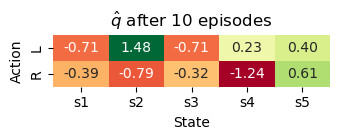

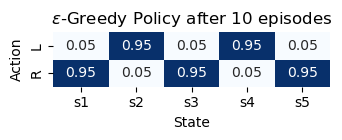

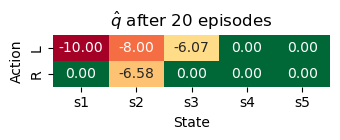

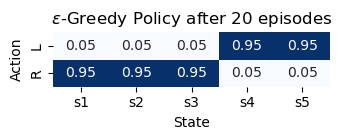

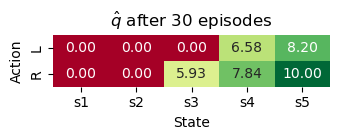

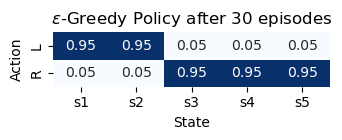

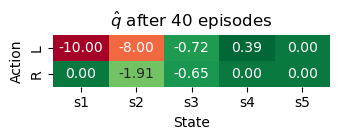

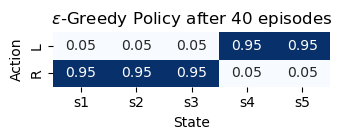

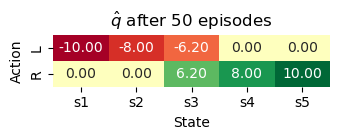

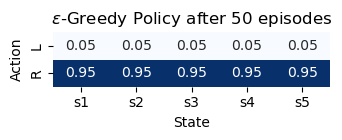

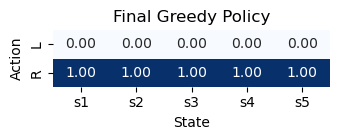

<Figure size 640x480 with 0 Axes>

In [7]:
# Exploring number of batches and episodes
episodes_per_batch = 10
num_batches = 5

# randomly initialise the seed
seed = np.random.seed()
for batch in range(num_batches):
    # By seeding the random number generator we ensure subsequent iterations
    # evolve identically up to the previous maximum number of episodes 
    np.random.seed(seed)
    # 
    greedy_policy, Q = monte_carlo_batch_optimisation(
        stair_sim, gamma, epsilon=epsilon, num_batches=batch,
        num_episodes=episodes_per_batch)
    egreedy_policy = get_epsilon_greedy_policy(epsilon, Q, absorbing=stair_mdp.absorbing)

    episodes_so_far = (batch+1)*episodes_per_batch
    plot_q_function(
        Q, stair_sim, states_as_rows=False,
       title=r"$\hat{q}$" + f" after {episodes_so_far} episodes")
    plot_policy_matrix(
        egreedy_policy, stair_sim, states_as_rows=False, 
        title=fr"$\varepsilon$-Greedy Policy after {episodes_so_far} episodes")
plot_policy_matrix(
    greedy_policy, stair_sim, states_as_rows=False, 
    title=f"Final Greedy Policy")
plt.tight_layout()


## Monte-carlo iterative optimisation

Monte-carlo iterative optimisation improves upon its batch optimisation counterpart in a number of ways. It no longer needs to store traces internally for a final estimate. Instead, after each episode it updates the Q-value estimates with the iterative update rule (see lectures).

The cell below shows the Q-estimates and $\varepsilon$-greedy policies after each small number of episdoes. Monte-carlo iterative optimisation can more naturally continue from arbitrary points and so does not need re-running from scratch. Results show that the best control policy is again approached in a noisy fashion, but here the convergence is much more rapid.

Iterative Monte-Carlo


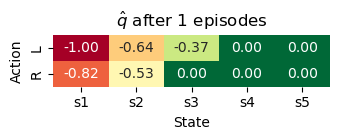

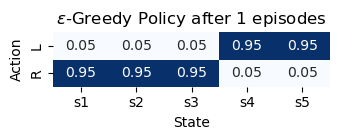

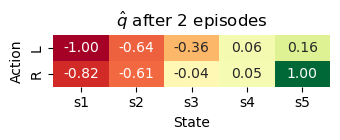

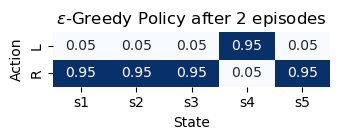

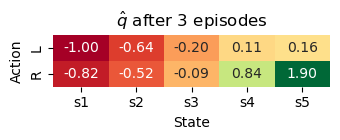

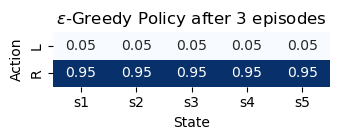

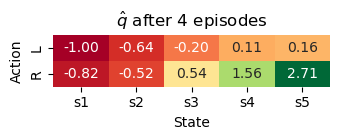

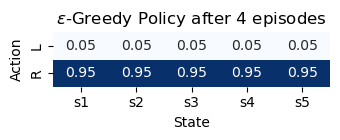

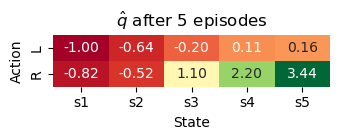

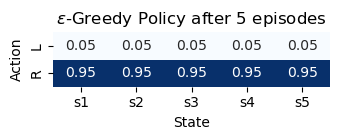

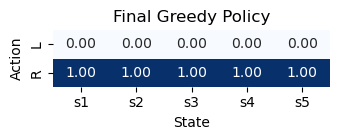

<Figure size 640x480 with 0 Axes>

In [8]:
# After each time window we'll plot the policy
np.random.seed()
print("Iterative Monte-Carlo")
epsilon = 0.1
episodes_per_window = 1
num_windows = 5
alpha = 0.1
Q = np.zeros((stair_sim.num_states, stair_sim.num_actions))
episodes_so_far = 0
for window in range(num_windows):
    greedy_policy, Q = monte_carlo_iterative_optimisation(
        stair_sim, gamma, epsilon=epsilon, alpha=alpha,
        num_episodes=episodes_per_window, initial_Q=Q)
    egreedy_policy = get_epsilon_greedy_policy(epsilon, Q, absorbing=stair_mdp.absorbing)
    episodes_so_far += episodes_per_window
    plot_q_function(
        Q, stair_sim, states_as_rows=False,
       title=r"$\hat{q}$" + f" after {episodes_so_far} episodes")
    plot_policy_matrix(
        egreedy_policy, stair_sim, states_as_rows=False, 
        title=fr"$\varepsilon$-Greedy Policy after {episodes_so_far} episodes")
plot_policy_matrix(
    greedy_policy, stair_sim, states_as_rows=False, 
    title=f"Final Greedy Policy")
plt.tight_layout()

## Summary and reflection

In this notebook, you have:
* Seen how Monte-carlo evaluation can be used to estimate state and state-action value functions from interactions with the environment
* Seen how the convergence of these algorithms is noisy and slower than dynamic programming approaches
* Derived epsilon greedy control policies from state-action value (q-function) estimates
* Applied Monte-carlo batch optimisation to learn to control the stair climbing MDP, without access to the model description, only via state-action-reward interactions
* Applied Monte-carlo iterative optimisation and seen the advantages this presents over its batch counterpart.

